In [1]:
import os
from google.colab import drive

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_703db1c40fe18c57c118e623ed0c60a8'

drive.mount('/content/drive')

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d /content/dataset/

print("Đã tải và giải nén dữ liệu hoàn tất!")

Mounted at /content/drive
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:15<00:00, 18.2MB/s]

Đã tải và giải nén dữ liệu hoàn tất!


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,827,905 (18.42 MB)

 Trainable params: 4,827,905 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6574 - loss: 0.7411
Epoch 1: val_accuracy improved from None to 0.62500, saving model to /content/drive/MyDrive/chest_xray_best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/chest_xray_best_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.7120 - loss: 0.6169 - val_accuracy: 0.6250 - val_loss: 0.7451
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8271 - loss: 0.3691
Epoch 2: val_accuracy improved from 0.62500 to 0.93750, saving model to /content/drive/MyDrive/chest_xray_best_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/chest_xray_best_model.keras
41/41 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.8495 - loss: 0.3351 - val_accuracy: 0.9375 - val_loss: 0.4335
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8724 - loss: 0.2914
Epoch 3: val_accuracy did not improve from 0.93750
41/41 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.88

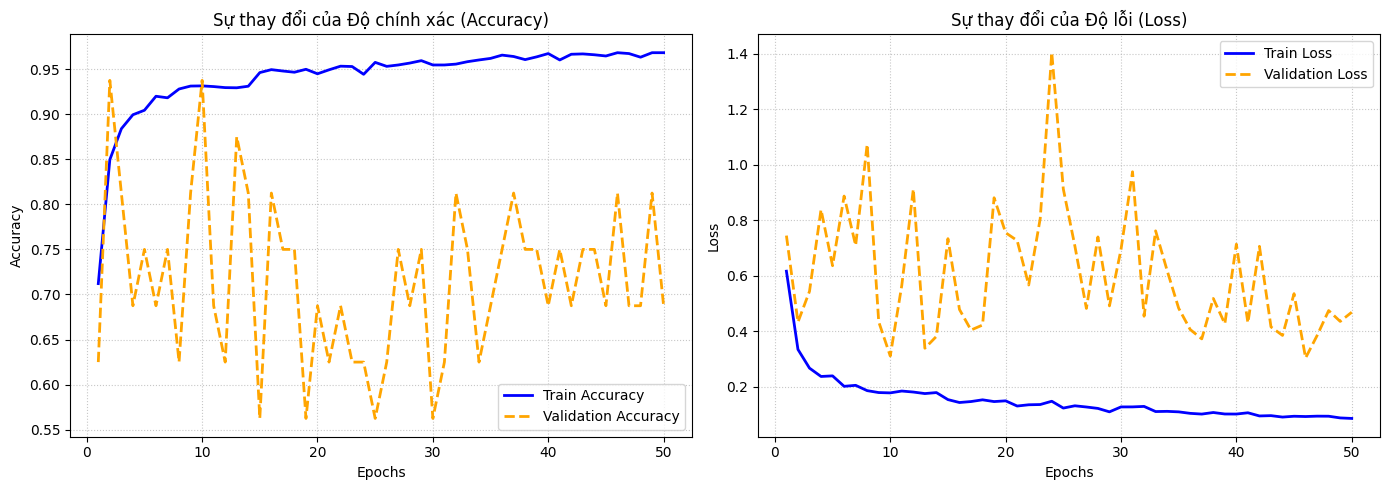

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt

train_dir = '/content/dataset/chest_xray/train'
val_dir = '/content/dataset/chest_xray/val'
test_dir = '/content/dataset/chest_xray/test'

# 2. Xử lý ảnh: Đưa giá trị pixel về khoảng [0, 1] và tăng cường dữ liệu
train_datagen = ImageDataGenerator(rescale=1./255, zoom_range=0.2, horizontal_flip=True)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# TỐI ƯU H100: Tăng batch_size=128 và thêm color_mode='grayscale' (ảnh X-quang đen trắng)
train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(150, 150), batch_size=128, class_mode='binary', color_mode='grayscale')
val_generator = val_test_datagen.flow_from_directory(
    val_dir, target_size=(150, 150), batch_size=128, class_mode='binary', color_mode='grayscale')
test_generator = val_test_datagen.flow_from_directory(
    test_dir, target_size=(150, 150), batch_size=128, class_mode='binary', color_mode='grayscale')

model = Sequential()

model.add(Input(shape=(150, 150, 1)))
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

checkpoint = ModelCheckpoint('/content/drive/MyDrive/chest_xray_best_model.keras', monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

history = model.fit(train_generator, epochs=50, validation_data=val_generator, callbacks=[checkpoint])

print("\n--- Đánh giá mô hình trên tập Test ---")
test_loss, test_acc = model.evaluate(test_generator)
print(f"Độ chính xác: {test_acc*100:.2f}%")

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linewidth=2, linestyle='--')
plt.title('Sự thay đổi của Độ chính xác (Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2, linestyle='--')
plt.title('Sự thay đổi của Độ lỗi (Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

In [1]:
!pip install transformers torch torchvision scikit-learn

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[*] Đang chạy trên thiết bị: cuda

--- Đang tải kiến trúc Vision Transformer... ---


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([2, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([2])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.



--- Bắt đầu huấn luyện... ---
Epoch 1/10 [278.7s] - Train Loss: 0.1099 - Val Acc: 93.75%
  -> Đã lưu model tốt nhất (Acc: 93.75%) vào Drive.
Epoch 2/10 [279.1s] - Train Loss: 0.0396 - Val Acc: 75.00%
Epoch 3/10 [277.0s] - Train Loss: 0.0316 - Val Acc: 81.25%
Epoch 4/10 [277.2s] - Train Loss: 0.0148 - Val Acc: 100.00%
  -> Đã lưu model tốt nhất (Acc: 100.00%) vào Drive.
Epoch 5/10 [279.8s] - Train Loss: 0.0157 - Val Acc: 100.00%
Epoch 6/10 [277.4s] - Train Loss: 0.0090 - Val Acc: 100.00%
Epoch 7/10 [276.3s] - Train Loss: 0.0018 - Val Acc: 87.50%
Epoch 8/10 [276.3s] - Train Loss: 0.0003 - Val Acc: 100.00%
Epoch 9/10 [279.1s] - Train Loss: 0.0001 - Val Acc: 100.00%
Epoch 10/10 [278.3s] - Train Loss: 0.0103 - Val Acc: 62.50%

--- Đánh giá mô hình trên tập Test ---

BÁO CÁO PHÂN LOẠI:
              precision    recall  f1-score   support

      NORMAL       0.99      0.62      0.76       234
   PNEUMONIA       0.81      1.00      0.90       390

    accuracy                           0.85 

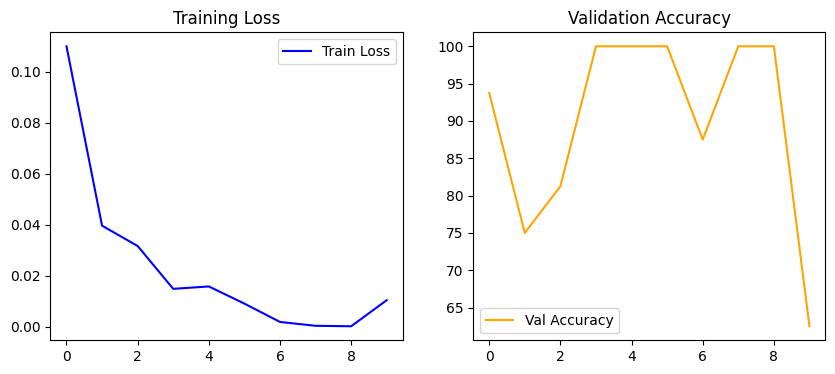

In [4]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from transformers import ViTForImageClassification
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from google.colab import drive

# --- 1. KẾT NỐI DRIVE VÀ TẢI DỮ LIỆU ---
drive.mount('/content/drive')

# Thiết lập Kaggle API và tải dataset nếu chưa có
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_703db1c40fe18c57c118e623ed0c60a8'
if not os.path.exists('/content/dataset/chest_xray'):
    !kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
    !unzip -q chest-xray-pneumonia.zip -d /content/dataset/
    print("Đã tải và giải nén dữ liệu hoàn tất!")

# --- 2. CẤU HÌNH ĐƯỜNG DẪN VÀ THIẾT BỊ ---
DATA_DIR = '/content/dataset/chest_xray'
MODEL_PATH = '/content/drive/MyDrive/vit_chest_xray_pytorch_best.pth'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[*] Đang chạy trên thiết bị: {device}")

# --- 3. TIỀN XỬ LÝ DỮ LIỆU (TRANSFORMS) ---
# ViT yêu cầu ảnh 224x224 và chuẩn hóa theo ImageNet
IMAGE_SIZE = 224
BATCH_SIZE = 32

transform_train = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val_test = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load Datasets
train_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'), transform=transform_train)
val_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'val'), transform=transform_val_test)
test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'), transform=transform_val_test)

# Tạo DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- 4. KHỞI TẠO MÔ HÌNH ViT ---
print("\n--- Đang tải kiến trúc Vision Transformer... ---")
model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=2,
    ignore_mismatched_sizes=True # Tự động bỏ lớp 1000 class cũ, thay bằng 2 class
).to(device)

# --- 5. CẤU HÌNH HUẤN LUYỆN ---
criterion = nn.CrossEntropyLoss()
# PyTorch + ViT kết hợp tốt nhất với AdamW, learning rate nhỏ
optimizer = optim.AdamW(model.parameters(), lr=3e-5, weight_decay=1e-4)

num_epochs = 10
best_acc = 0.0
history = {'train_loss': [], 'val_acc': []}

# --- 6. VÒNG LẶP HUẤN LUYỆN ---
print("\n--- Bắt đầu huấn luyện... ---")
for epoch in range(num_epochs):
    start_time = time.time()

    # Chế độ Train
    model.train()
    running_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        # Đầu ra của model HF là một object, lấy thuộc tính .logits
        outputs = model(imgs).logits
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)

    # Chế độ Evaluate (Đánh giá trên tập Val)
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs).logits
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    history['train_loss'].append(avg_train_loss)
    history['val_acc'].append(val_acc)

    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{num_epochs} [{epoch_time:.1f}s] - Train Loss: {avg_train_loss:.4f} - Val Acc: {val_acc:.2f}%")

    # Lưu mô hình nếu tốt hơn
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), MODEL_PATH)
        print(f"  -> Đã lưu model tốt nhất (Acc: {val_acc:.2f}%) vào Drive.")

# --- 7. ĐÁNH GIÁ TRÊN TẬP TEST ---
print("\n--- Đánh giá mô hình trên tập Test ---")
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs).logits
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nBÁO CÁO PHÂN LOẠI:")
print(classification_report(all_labels, all_preds, target_names=["NORMAL", "PNEUMONIA"]))

# Vẽ biểu đồ nhanh
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['val_acc'], label='Val Accuracy', color='orange')
plt.title('Validation Accuracy')
plt.legend()
plt.show()